In [33]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
import numpy as np

df_2022 = pd.read_csv('../../Projektdatensaetze/2022/FahrradBonn2022_COPY.csv',
                 sep=';', skiprows=1)
df_2022.drop(index=df_2022.index[-1],axis=0,inplace=True)
df_2022['time'] = pd.to_datetime(df_2022['time'], format='%Y-%m-%d %H:%M')

df_2022['days'] = df_2022['time'].dt.date

df_day_bonn = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Bonn'].sum()
df_day_koeln = df_2022.groupby('days')['5.07 BN - Estermannufer Radfahrer Ri. Köln'].sum()

df_22_sum = df_day_bonn + df_day_koeln

df_2023 = pd.read_csv('../../Projektdatensaetze/2023/Fahrradzaehlstellen2023_stuendlich_RENAMED.csv',
                 sep=';')

df_2023['time'] = pd.to_datetime(df_2023['time'], format='%d.%m.%Y %H:%M')
df_2023['time'] = df_2023['time'].dt.strftime('%Y-%m-%d %H:%M')
df_2023['time'] = pd.to_datetime(df_2023['time'], format='%Y-%m-%d %H:%M')
#print(type(df_2023['time']))
#display(df_2023)
df_2023['days'] = df_2023['time'].dt.date


df_day_23 = df_2023.groupby('days')['5.07 BN - Estermannufer'].sum()
#display(df_day_23)


In [34]:
df_ = pd.DataFrame()
df_['5.07 BN - Estermannufer']= df_day_bonn + df_day_koeln
df = pd.concat([df_, df_day_23])

#display(df)
df = pd.DataFrame(df)
df = df.asfreq('d')
#df['5.07 BN - Estermannufer'].dtype


In [35]:
#prüfe auf Stationarität
from statsmodels.tsa.stattools import adfuller
result = adfuller(df)
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -1.4131
p-value = 0.5760


Datenaufbereitung

1. Vergleiche Autokorrelation vs. partielle Autokorrelation
2. teile in Trainings- und Testdaten ein
3. Stelle Stationarität her

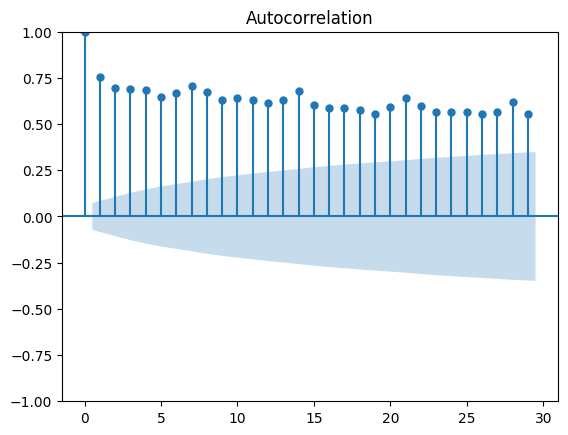

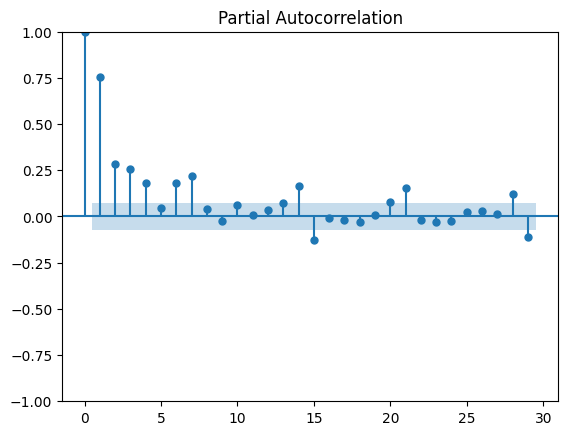

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df)
plot_pacf(df)
plt.show()

In [37]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]
display(df_train)


,5.07 BN - Estermannufer
days,
2022-01-01,307.0
2022-01-02,182.0
2022-01-03,106.0
2022-01-04,78.0
2022-01-05,58.0
...,...
2023-10-15,358.0
2023-10-16,531.0
2023-10-17,580.0


In [38]:
df_train.loc[:,'differences'] = df_train['5.07 BN - Estermannufer'].diff().fillna(0)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -8.9770
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_7956\3088967297.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train['5.07 BN - Estermannufer'].diff().fillna(0)


In [39]:
display(df_train)

,5.07 BN - Estermannufer,differences
days,,
2022-01-01,307.0,0.0
2022-01-02,182.0,-125.0
2022-01-03,106.0,-76.0
2022-01-04,78.0,-28.0
2022-01-05,58.0,-20.0
...,...,...
2023-10-15,358.0,-129.0
2023-10-16,531.0,173.0
2023-10-17,580.0,49.0


                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(1, 1, 0)   Log Likelihood               -4681.124
Date:                     Tue, 10 Dec 2024   AIC                           9366.248
Time:                             11:00:57   BIC                           9375.221
Sample:                         01-01-2022   HQIC                          9369.727
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3727      0.024    -15.449      0.000      -0.420      -0.325
sigma2       9.25e+04   2488.030     37.178      0.000    8.76e+04    9.74e+04
Ljung-Box (L

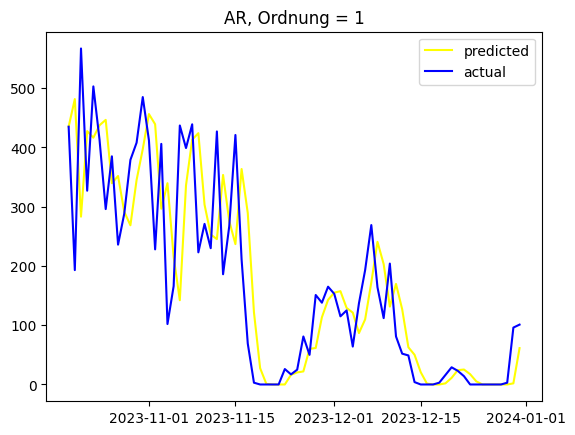

mean absolute error (mae): ARIMA: 68.2362, simple: 75.1507
mean squared error (mse): ARIMA: 10429.3042, simple: 12769.9726
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(2, 1, 0)   Log Likelihood               -4648.663
Date:                     Tue, 10 Dec 2024   AIC                           9303.325
Time:                             11:01:02   BIC                           9316.784
Sample:                         01-01-2022   HQIC                          9308.543
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4874      0.027    -18.258    

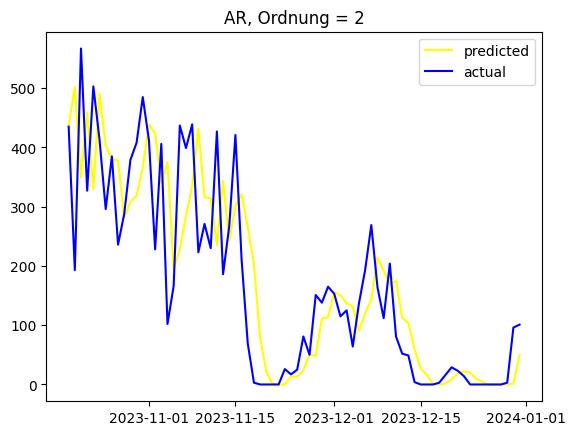

mean absolute error (mae): ARIMA: 72.0102, simple: 75.1507
mean squared error (mse): ARIMA: 10385.9980, simple: 12769.9726
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(3, 1, 0)   Log Likelihood               -4633.025
Date:                     Tue, 10 Dec 2024   AIC                           9274.050
Time:                             11:01:04   BIC                           9291.995
Sample:                         01-01-2022   HQIC                          9281.007
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5538      0.027    -20.353    

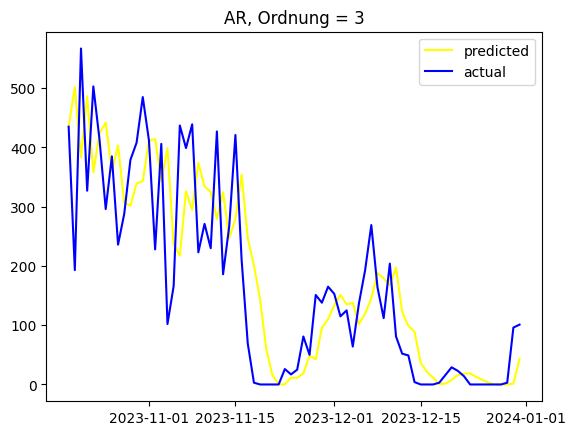

mean absolute error (mae): ARIMA: 74.7229, simple: 75.1507
mean squared error (mse): ARIMA: 10640.9010, simple: 12769.9726
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(4, 1, 0)   Log Likelihood               -4631.459
Date:                     Tue, 10 Dec 2024   AIC                           9272.918
Time:                             11:01:05   BIC                           9295.348
Sample:                         01-01-2022   HQIC                          9281.614
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5687      0.027    -21.159    

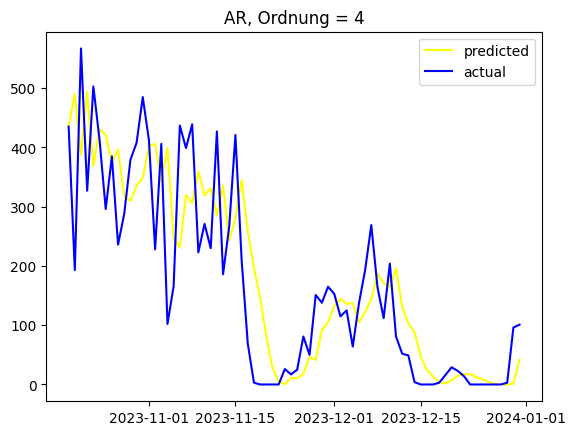

mean absolute error (mae): ARIMA: 74.6530, simple: 75.1507
mean squared error (mse): ARIMA: 10319.7393, simple: 12769.9726
                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(5, 1, 0)   Log Likelihood               -4617.402
Date:                     Tue, 10 Dec 2024   AIC                           9246.803
Time:                             11:01:06   BIC                           9273.720
Sample:                         01-01-2022   HQIC                          9257.239
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5831      0.027    -21.614    

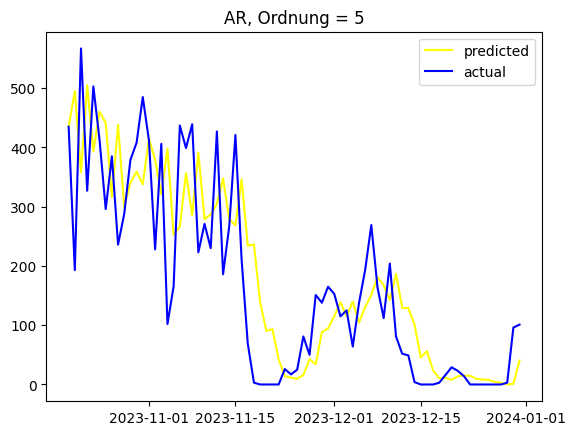

mean absolute error (mae): ARIMA: 77.3856, simple: 75.1507
mean squared error (mse): ARIMA: 10945.3507, simple: 12769.9726


In [42]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 6):
    p, d, q = i, 1, 0
    #arima = SARIMAX(df_train['differences'], order=(p, d, q), freq='D')
    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)
    
    # Vorhersage
    predicted = result_new.predict(start='2023-10-20')
    tmp = pd.DataFrame(predicted)
    #tmp['differences'] = tmp['predicted_mean']
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    #display(tmp)
    #display(df_train)
    
    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)
    

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    
    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r['5.07 BN - Estermannufer'].iloc[656: 730], color='yellow', label='predicted')
    plt.plot(df['5.07 BN - Estermannufer'].iloc[656: 730], color='blue', label='actual')
    plt.legend()
    plt.show()
    
    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()
    
    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    
    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))

                                  SARIMAX Results                                  
Dep. Variable:     5.07 BN - Estermannufer   No. Observations:                  657
Model:                    SARIMAX(0, 1, 1)   Log Likelihood               -4613.494
Date:                     Tue, 10 Dec 2024   AIC                           9230.989
Time:                             11:26:28   BIC                           9239.961
Sample:                         01-01-2022   HQIC                          9234.467
                              - 10-19-2023                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.8111      0.016    -49.747      0.000      -0.843      -0.779
sigma2      7.507e+04   1921.816     39.064      0.000    7.13e+04    7.88e+04
Ljung-Box (L

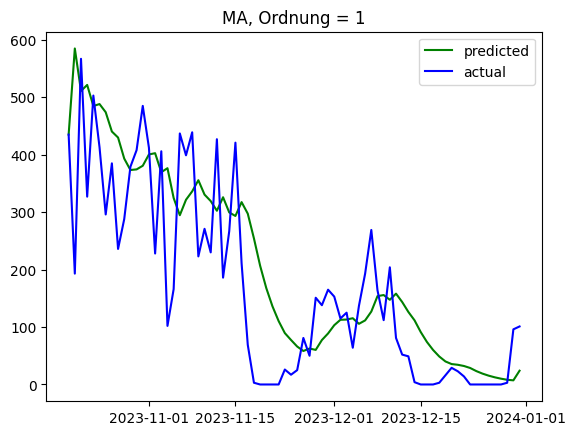

mean absolute error (mae): ARIMA: 84.6133, simple: 75.1507
mean squared error (mse): ARIMA: 12461.8974, simple: 12769.9726


In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')

for i in range(1, 2):
    p, d, q = 0, 1, i
    #arima = SARIMAX(df_train['differences'], order=(p, d, q), freq='D')
    arima = SARIMAX(df_train['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result = arima.fit()
    print(result.summary())
    
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['5.07 BN - Estermannufer'], order=(p, d, q), freq='D')
    result_new = model.filter(result.params)
    
    # Vorhersage
    predicted = result_new.predict(start='2023-10-20')
    tmp = pd.DataFrame(predicted)
    #tmp['differences'] = tmp['predicted_mean']
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    #display(tmp)
    #display(df_train)
    
    # Mergen der Daten
    df_r = pd.concat([df_train, tmp['crossings']], axis=1)

    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)
    

    df_r['5.07 BN - Estermannufer'] = df_r['5.07 BN - Estermannufer'].fillna(df_r['crossings'])
    
    # Plotten
    plt.title('MA, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r['5.07 BN - Estermannufer'].iloc[656: 730], color='green', label='predicted')
    plt.plot(df['5.07 BN - Estermannufer'].iloc[656: 730], color='blue', label='actual')
    plt.legend()
    plt.show()
    
    y_pred_simple = df_test['5.07 BN - Estermannufer'].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train['5.07 BN - Estermannufer'].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()
    
    mae_arima = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - predicted))
    mse_arima = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - predicted))
    mae_simple = np.mean(np.abs(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test['5.07 BN - Estermannufer'] - y_pred_simple))
    
    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))

In [9]:
#logarithmiere die Daten vor Stationaritätsherstellung
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(1, 10))
#df_train['scaled'] = scaler.fit_transform(df_train[['5.07 BN - Estermannufer']])
df_train.loc[:, 'scaled'] = scaler.fit_transform(df_train[['5.07 BN - Estermannufer']])
df_train.loc[:, 'close_log'] = np.log(df_train['scaled'])
df_train.loc[:, 'first_diff'] = df_train['close_log'].diff()


#df_train['close_log'] = np.log(df_train['scaled'])
#df_train['first_diff'] = df_train['close_log'].diff()
display(df_train)

,5.07 BN - Estermannufer,differences,scaled,close_log,first_diff
days,,,,,
2022-01-01,307.0,0.0,2.045008,0.715401,NaN
2022-01-02,182.0,-125.0,1.619516,0.482127,-0.233274
2022-01-03,106.0,-76.0,1.360817,0.308085,-0.174042
2022-01-04,78.0,-28.0,1.265507,0.235473,-0.072613
2022-01-05,58.0,-20.0,1.197428,0.180176,-0.055297
...,...,...,...,...,...
2023-10-15,358.0,-129.0,2.218608,0.796880,-0.180587
2023-10-16,531.0,173.0,2.807489,1.032290,0.235410
2023-10-17,580.0,49.0,2.974281,1.090002,0.057712


Test statistic = -10.8117
p-value = 0.0000


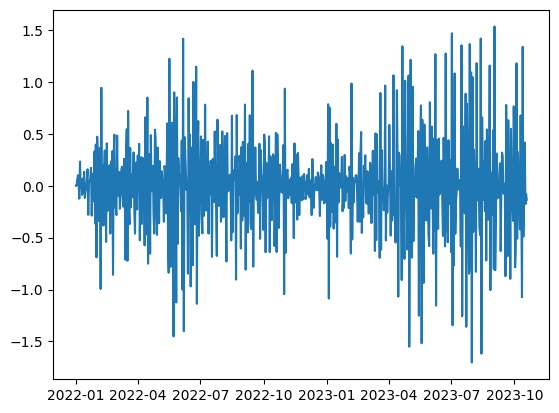

In [10]:
df_train.loc[:,'first_diff']= df_train['first_diff'].diff().fillna(0)
result = adfuller(df_train['first_diff'])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))
plt.plot(df_train['first_diff'])

                               SARIMAX Results                                
Dep. Variable:              close_log   No. Observations:                  657
Model:               SARIMAX(1, 1, 0)   Log Likelihood                 -96.194
Date:                Tue, 10 Dec 2024   AIC                            196.388
Time:                        09:43:49   BIC                            205.361
Sample:                    01-01-2022   HQIC                           199.867
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3447      0.033    -10.505      0.000      -0.409      -0.280
sigma2         0.0785      0.004     22.263      0.000       0.072       0.085
Ljung-Box (L1) (Q):                   6.76   Jarque-

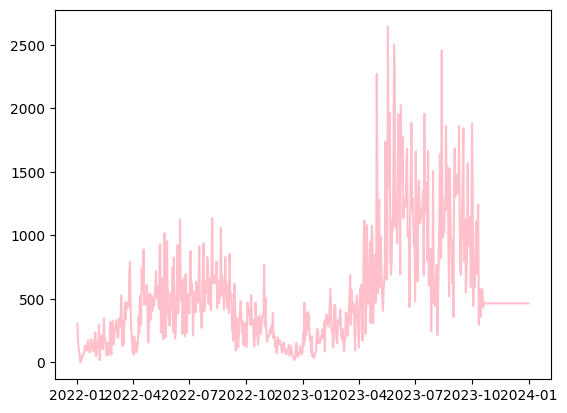

                               SARIMAX Results                                
Dep. Variable:              close_log   No. Observations:                  657
Model:               SARIMAX(1, 2, 0)   Log Likelihood                -329.692
Date:                Tue, 10 Dec 2024   AIC                            663.383
Time:                        09:43:50   BIC                            672.352
Sample:                    01-01-2022   HQIC                           666.861
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5757      0.028    -20.484      0.000      -0.631      -0.521
sigma2         0.1601      0.007     21.431      0.000       0.145       0.175
Ljung-Box (L1) (Q):                  44.54   Jarque-

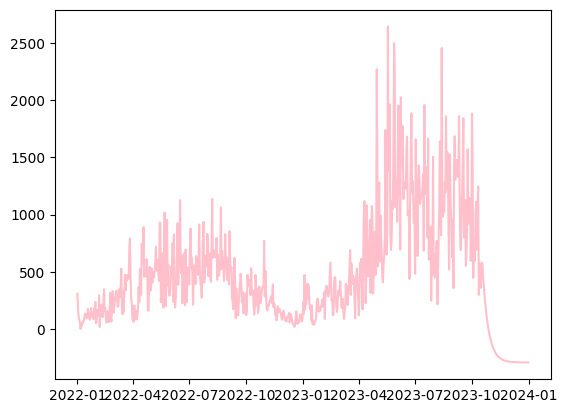

                               SARIMAX Results                                
Dep. Variable:              close_log   No. Observations:                  657
Model:               SARIMAX(1, 3, 0)   Log Likelihood                -623.502
Date:                Tue, 10 Dec 2024   AIC                           1251.003
Time:                        09:43:52   BIC                           1259.970
Sample:                    01-01-2022   HQIC                          1254.480
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6919      0.025    -27.728      0.000      -0.741      -0.643
sigma2         0.3937      0.018     21.645      0.000       0.358       0.429
Ljung-Box (L1) (Q):                  91.28   Jarque-

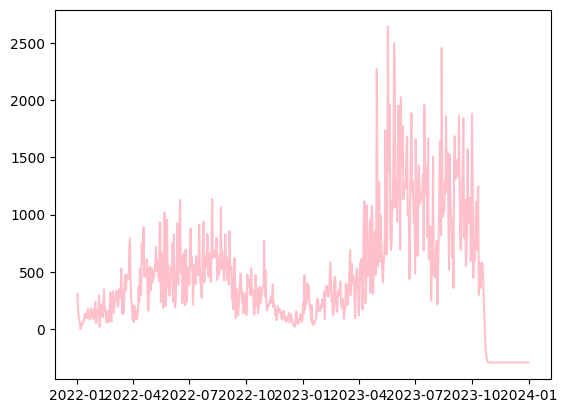

                               SARIMAX Results                                
Dep. Variable:              close_log   No. Observations:                  657
Model:               SARIMAX(1, 4, 0)   Log Likelihood                -948.855
Date:                Tue, 10 Dec 2024   AIC                           1901.711
Time:                        09:43:53   BIC                           1910.674
Sample:                    01-01-2022   HQIC                          1905.187
                         - 10-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7629      0.022    -34.284      0.000      -0.806      -0.719
sigma2         1.0692      0.052     20.479      0.000       0.967       1.172
Ljung-Box (L1) (Q):                 136.82   Jarque-

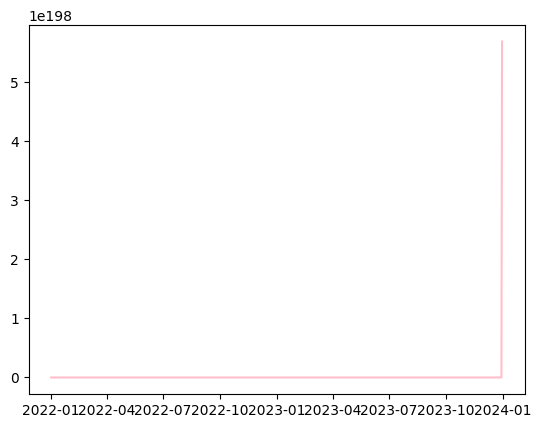

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX


for i in range(1,5):
    p,d,q = 1,i,0
    arima = SARIMAX(df_train['close_log'], order=(p,d,q))
                    #, seasonal_order=(p,d,q, 7))
    result = arima.fit()
    print(result.summary())
    df['close_log'] = df_train['close_log']
    #display(df)
    model = SARIMAX(df['close_log'], order=(p,d,q))
    result_new = model.filter(result.params)
    y_pred_test = result_new.predict(start='2023-10-19')
    predicted =  np.exp(y_pred_test)
    tmp = pd.DataFrame(predicted)
    tmp['scaled'] = predicted
    tmp['days'] = tmp.index.date
    
    df_r = pd.concat([df, df_train['scaled']], axis=1)


    #df_r.index = df_r.index.date
    df_r = df_r.merge(tmp, how='left', left_index=True, right_index=True)
    df_r['scaled'] = df_r['scaled_x'].fillna(df_r['scaled_y'])
    #display(df_r)
    
    #df_r= pd.concat([df_r, tmp], axis=1).combine_first(df_r)
    df_r['predicted'] = scaler.inverse_transform(df_r[['scaled']])
    #display(df_r)
    plt.plot(df_r['predicted'], color='pink')
    plt.show()
    #plt.plot(df['5.07 BN - Estermannufer'])
    #plt.show()
    #display(y_pred_test)

In [12]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
p,d,q = 1,1,0
arima = SARIMAX(df_train['first_diff'], order=(p,d,q), seasonal_order=(p,d,q, 7))
result = arima.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:                        first_diff   No. Observations:                  657
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 7)   Log Likelihood                -686.737
Date:                           Tue, 10 Dec 2024   AIC                           1379.473
Time:                                   09:43:56   BIC                           1392.900
Sample:                               01-01-2022   HQIC                          1384.681
                                    - 10-19-2023                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7085      0.024    -29.442      0.000      -0.756      -0.661
ar.S.L7       -0.5183      0.027    -19.427      0.000      -0.571      -0.466
sigma2         0.4837      0.021     23.160      0.000       0.443       0.525
===================================================================================
Ljung-Box (L1) (Q):                  87.65   Jarque-Bera (JB):                49.82
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.82   Skew:                             0.02
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [13]:
df['close_log'] = df_train['close_log']


In [14]:
predicted =  np.exp(y_pred_test)
tmp = pd.DataFrame(predicted)
tmp['scaled'] = predicted
tmp['days'] = tmp.index.date

df_r = pd.concat([df, df_train['scaled']], axis=1)
#df_r.index = df_r.index.date
df_r = df_r.merge(tmp, how='left', left_index=True, right_index=True)
df_r['scaled'] = df_r['scaled_x'].fillna(df_r['scaled_y'])
#display(df_r)

#df_r= pd.concat([df_r, tmp], axis=1).combine_first(df_r)
df_r['predicted'] = scaler.inverse_transform(df_r[['scaled']])
'''
display(df_r)
plt.plot(df_r['predicted'], color='pink')
plt.show()
plt.plot(df['5.07 BN - Estermannufer'])
plt.show()
'''

"\ndisplay(df_r)\nplt.plot(df_r['predicted'], color='pink')\nplt.show()\nplt.plot(df['5.07 BN - Estermannufer'])\nplt.show()\n"